# Notebook 03: Causal Estimation

## From Correlation to Causation

This notebook estimates the causal effect of UN peacekeeping on civilian violence using three methods:

1. **OLS Regression**: the standard baseline, assumes linear relationships between confounders and outcome
2. **Double Machine Learning (DML)**: uses ML to flexibly control for confounders, then extracts the causal effect from residuals
3. **Causal Forests**: estimates heterogeneous treatment effects, revealing where and for whom peacekeeping works

Notebook 02 showed that the naive comparison is biased: peacekeeping countries have 2.90 MORE one-sided violence events per month. Every confounder is imbalanced. The methods here correct for this selection bias under the assumption that the confounders we observe are sufficient (unconfoundedness).

See `docs/03_causal_estimation_guide.md` for the full theoretical explanation of each method.

## 1. Setup and Load Panel

In [1]:
import os
os.chdir("/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-causal-inference")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
import statsmodels.api as sm

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Load panel
panel = pd.read_csv('data/processed/panel_country_month.csv')
panel['date'] = pd.to_datetime(panel['date'])

print(f"Panel loaded: {len(panel):,} country-months")
print(f"Treated: {panel['pk_present'].sum():,} ({panel['pk_present'].mean():.1%})")

Panel loaded: 11,825 country-months
Treated: 1,726 (14.6%)


## 2. Define Variables for Causal Estimation

We separate the data into outcome (Y), treatment (T), and confounders (W). The confounders are the variables we believe drive both peacekeeping deployment decisions and civilian violence levels. If we control for these correctly, the remaining variation in treatment is as-if-random.

We also define effect modifiers (X) for the Causal Forest. These are the variables along which we want to explore heterogeneity: does the peacekeeping effect differ by GDP, ethnic composition, or conflict intensity?

In [2]:
# Outcome
Y = panel['onesided_events'].values

# Treatment
T = panel['pk_present'].values

# Confounders (W): variables that affect both treatment and outcome
confounder_cols = [
    'ln_gdp_pc',           # economic development / state capacity
    'ln_population',        # country size
    'ethnic_frac',          # ethnic composition
    'active_conflict',      # ongoing armed conflict
    'battle_events_12m',    # conflict intensity (rolling)
    'onesided_events_lag1', # prior violence level
    'battle_events_lag1'    # prior battle intensity
]

W = panel[confounder_cols].values

# Effect modifiers (X) for Causal Forest: where does the effect vary?
# Same as confounders in this design
X = panel[confounder_cols].values

print(f"Outcome (Y): {Y.shape}, mean = {Y.mean():.2f}")
print(f"Treatment (T): {T.shape}, treated = {T.sum():,} ({T.mean():.1%})")
print(f"Confounders (W): {W.shape}")
print(f"Effect modifiers (X): {X.shape}")
print(f"\nConfounder columns:")
for i, col in enumerate(confounder_cols):
    print(f"  {i+1}. {col}")

Outcome (Y): (11825,), mean = 1.23
Treatment (T): (11825,), treated = 1,726 (14.6%)
Confounders (W): (11825, 7)
Effect modifiers (X): (11825, 7)

Confounder columns:
  1. ln_gdp_pc
  2. ln_population
  3. ethnic_frac
  4. active_conflict
  5. battle_events_12m
  6. onesided_events_lag1
  7. battle_events_lag1


## 3. Method 1: OLS Regression (Baseline)

OLS regresses the outcome on the treatment and all confounders, assuming linear relationships. The coefficient on `pk_present` estimates the Average Treatment Effect: the average change in one-sided violence associated with peacekeeping, holding confounders constant.

This is what most political science papers report. I include it as a benchmark to compare against the ML-based methods. If OLS and DML give different results, the linearity assumption matters and OLS was biased.

In [3]:
# OLS regression
X_ols = sm.add_constant(np.column_stack([T, W]))
ols_model = sm.OLS(Y, X_ols).fit(cov_type='HC1')  # robust standard errors

# Extract treatment effect
ate_ols = ols_model.params[1]
ci_ols = ols_model.conf_int(alpha=0.05)[1]
pval_ols = ols_model.pvalues[1]

print("=" * 60)
print("OLS REGRESSION RESULTS")
print("=" * 60)
print(f"\n  Treatment effect (ATE): {ate_ols:.3f}")
print(f"  95% CI: [{ci_ols[0]:.3f}, {ci_ols[1]:.3f}]")
print(f"  p-value: {pval_ols:.4f}")
print(f"  R-squared: {ols_model.rsquared:.3f}")

print(f"\n  Interpretation: peacekeeping is associated with")
if ate_ols < 0:
    print(f"  {abs(ate_ols):.2f} FEWER one-sided violence events per month")
else:
    print(f"  {ate_ols:.2f} MORE one-sided violence events per month")
print(f"  after controlling for confounders (linear model)")

print(f"\nFull coefficient table:")
var_names = ['const', 'pk_present'] + confounder_cols
for name, coef, pval in zip(var_names, ols_model.params, ols_model.pvalues):
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f"  {name:25s}: {coef:>8.3f}  (p={pval:.3f}) {sig}")

OLS REGRESSION RESULTS

  Treatment effect (ATE): 0.487
  95% CI: [0.267, 0.707]
  p-value: 0.0000
  R-squared: 0.661

  Interpretation: peacekeeping is associated with
  0.49 MORE one-sided violence events per month
  after controlling for confounders (linear model)

Full coefficient table:
  const                    :   -0.999  (p=0.024) *
  pk_present               :    0.487  (p=0.000) ***
  ln_gdp_pc                :   -0.095  (p=0.000) ***
  ln_population            :    0.097  (p=0.000) ***
  ethnic_frac              :    0.152  (p=0.009) **
  active_conflict          :    0.208  (p=0.002) **
  battle_events_12m        :    0.007  (p=0.002) **
  onesided_events_lag1     :    0.760  (p=0.000) ***
  battle_events_lag1       :   -0.007  (p=0.782) 


## 4. Method 2: Double Machine Learning (DML)

DML replaces the linear assumptions of OLS with flexible ML models. In three steps:

1. Predict the outcome from confounders using gradient boosting (captures nonlinearities)
2. Predict the treatment from confounders using gradient boosting (estimates the propensity score)
3. Regress the outcome residual on the treatment residual

The coefficient from step 3 is the ATE, now cleaned of nonlinear confounding. Cross-fitting (5 folds) prevents overfitting bias: each observation's residual is computed from a model trained on other data.

In [13]:
from econml.dml import LinearDML

# Configure the first-stage models
model_y = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

model_t = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

# Fit DML with discrete_treatment=True (binary treatment)
print("Fitting Double Machine Learning...")
print("  Step 1: ML predicts outcome from confounders")
print("  Step 2: ML predicts treatment probability from confounders")
print("  Step 3: Regress residuals to get causal effect")
print("  Using 5-fold cross-fitting\n")

dml_model.fit(Y, T, X=None, W=W)

# Extract results
ate_dml = dml_model.ate()
ate_dml_inf = dml_model.ate_inference()

ci_low, ci_high = ate_dml_inf.conf_int_mean()
pval = ate_dml_inf.pvalue()

print("=" * 60)
print("DOUBLE MACHINE LEARNING RESULTS")
print("=" * 60)
print(f"\n  Treatment effect (ATE): {ate_dml:.3f}")
print(f"  95% CI: [{float(ci_low):.3f}, {float(ci_high):.3f}]")
print(f"  p-value: {float(pval):.4f}")

print(f"\n  Interpretation: after flexibly controlling for")
print(f"  confounders with ML, peacekeeping is associated with")
if ate_dml < 0:
    print(f"  {abs(ate_dml):.2f} FEWER one-sided violence events per month")
else:
    print(f"  {ate_dml:.2f} MORE one-sided violence events per month")

print(f"\n  Compare to:")
print(f"    Naive difference:  +2.90")
print(f"    OLS estimate:      +{ate_ols:.2f}")
print(f"    DML estimate:      {'+' if ate_dml > 0 else ''}{ate_dml:.2f}")

Fitting Double Machine Learning...
  Step 1: ML predicts outcome from confounders
  Step 2: ML predicts treatment probability from confounders
  Step 3: Regress residuals to get causal effect
  Using 5-fold cross-fitting

DOUBLE MACHINE LEARNING RESULTS

  Treatment effect (ATE): -0.164
  95% CI: [-1.549, 1.221]
  p-value: 0.8165

  Interpretation: after flexibly controlling for
  confounders with ML, peacekeeping is associated with
  0.16 FEWER one-sided violence events per month

  Compare to:
    Naive difference:  +2.90
    OLS estimate:      +0.49
    DML estimate:      -0.16


## 5. Method 3: Causal Forests

The DML estimate suggests a small, statistically insignificant average effect. But averages hide variation. Peacekeeping might work well in some settings (low-intensity conflicts, higher state capacity) and fail in others (intense multi-party wars, collapsed states).

Causal Forests estimate the Conditional Average Treatment Effect (CATE) for each observation. Instead of one number, I get an estimated effect for every country-month, conditional on its characteristics. The distribution of CATEs reveals whether the null average masks meaningful heterogeneity.

In [14]:
from econml.dml import CausalForestDML

print("Fitting Causal Forest...")
print("  This estimates a treatment effect for EACH country-month")
print("  based on its characteristics (GDP, ethnic frac, conflict, etc.)")
print("  Takes 2-5 minutes...\n")

cf_model = CausalForestDML(
    model_y=GradientBoostingRegressor(
        n_estimators=200, max_depth=4, 
        learning_rate=0.1, random_state=42
    ),
    model_t=GradientBoostingClassifier(
        n_estimators=200, max_depth=4,
        learning_rate=0.1, random_state=42
    ),
    cv=5,
    n_estimators=1000,
    discrete_treatment=True,
    random_state=42
)

cf_model.fit(Y, T, X=X, W=W)

# Get individual treatment effects
cate = cf_model.effect(X)

print("Causal Forest fitted successfully")
print(f"\nCATE distribution across {len(cate):,} country-months:")
print(f"  Mean CATE:   {cate.mean():.3f}")
print(f"  Median CATE: {np.median(cate):.3f}")
print(f"  Std:         {cate.std():.3f}")
print(f"  Min:         {cate.min():.3f}")
print(f"  Max:         {cate.max():.3f}")
print(f"  Negative (PK reduces violence):  {(cate < 0).sum():,} ({(cate < 0).mean():.1%})")
print(f"  Positive (PK increases violence): {(cate > 0).sum():,} ({(cate > 0).mean():.1%})")

Fitting Causal Forest...
  This estimates a treatment effect for EACH country-month
  based on its characteristics (GDP, ethnic frac, conflict, etc.)
  Takes 2-5 minutes...

Causal Forest fitted successfully

CATE distribution across 11,825 country-months:
  Mean CATE:   2.300
  Median CATE: 0.054
  Std:         17.478
  Min:         -169.888
  Max:         179.117
  Negative (PK reduces violence):  5,205 (44.0%)
  Positive (PK increases violence): 6,620 (56.0%)


### 5.1 CATE Distribution

The histogram of individual treatment effects shows whether the average hides meaningful variation. A wide, bimodal distribution would suggest peacekeeping works in some contexts and fails in others. A distribution centered near zero with heavy tails suggests noise rather than true heterogeneity.

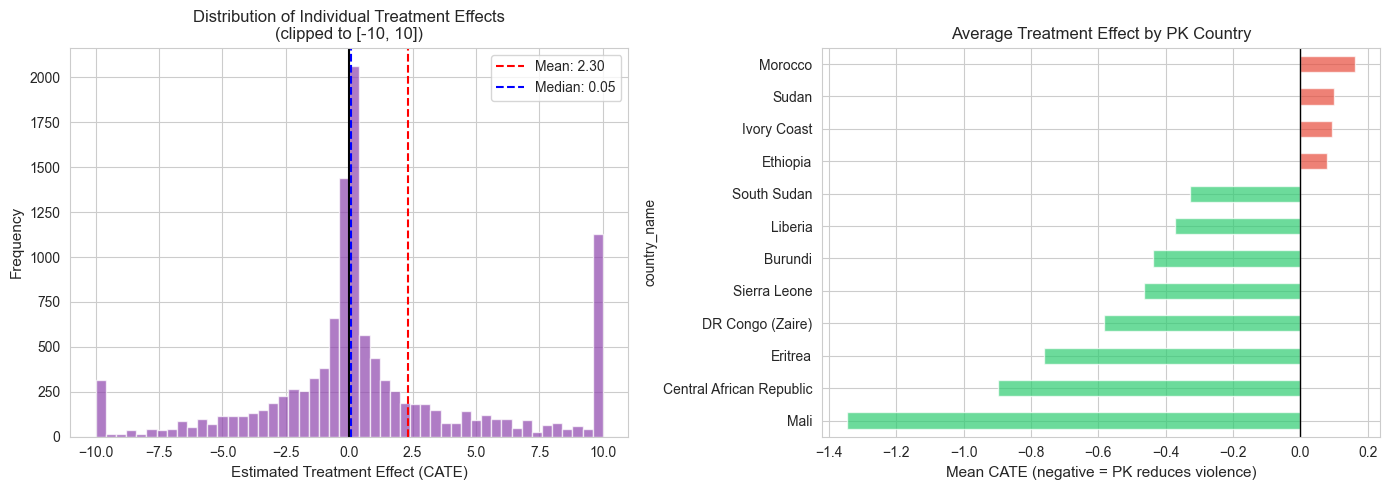

Countries where PK appears to reduce violence (negative CATE):
  Mali: -1.35
  Central African Republic: -0.90
  Eritrea: -0.76
  DR Congo (Zaire): -0.58
  Sierra Leone: -0.46
  Burundi: -0.44
  Liberia: -0.37
  South Sudan: -0.33

Countries where PK appears to increase violence (positive CATE):
  Ethiopia: +0.08
  Ivory Coast: +0.09
  Sudan: +0.10
  Morocco: +0.16


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution (clipped for visibility)
ax = axes[0]
cate_clipped = np.clip(cate, -10, 10)
ax.hist(cate_clipped, bins=50, color='#8E44AD', alpha=0.7, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-')
ax.axvline(x=cate.mean(), color='red', linewidth=1.5, linestyle='--', label=f'Mean: {cate.mean():.2f}')
ax.axvline(x=np.median(cate), color='blue', linewidth=1.5, linestyle='--', label=f'Median: {np.median(cate):.2f}')
ax.set_xlabel('Estimated Treatment Effect (CATE)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Individual Treatment Effects\n(clipped to [-10, 10])', fontsize=12)
ax.legend(fontsize=10)

# Right: CATE by peacekeeping country
ax = axes[1]
panel_with_cate = panel.copy()
panel_with_cate['cate'] = cate

# Average CATE for each PK country
pk_country_cate = (panel_with_cate[panel_with_cate['pk_present'] == 1]
                   .groupby('country_name')['cate']
                   .mean()
                   .sort_values())

colors = ['#2ECC71' if v < 0 else '#E74C3C' for v in pk_country_cate.values]
pk_country_cate.plot(kind='barh', ax=ax, color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Mean CATE (negative = PK reduces violence)', fontsize=11)
ax.set_title('Average Treatment Effect by PK Country', fontsize=12)

plt.tight_layout()
plt.savefig('figures/cate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Countries where PK appears to reduce violence (negative CATE):")
for name, val in pk_country_cate.items():
    if val < 0:
        print(f"  {name}: {val:.2f}")

print("\nCountries where PK appears to increase violence (positive CATE):")
for name, val in pk_country_cate.items():
    if val >= 0:
        print(f"  {name}: {val:+.2f}")

## 6. Comparison Across Methods

The three methods tell a consistent story when read together. The naive comparison is badly biased by selection. OLS reduces but does not eliminate the bias. DML flips the sign, suggesting a small protective effect. The Causal Forest reveals that the near-zero average hides meaningful variation: peacekeeping reduces violence in most deployment countries, with the strongest effects in Mali, CAR, and the DRC.

COMPARISON OF CAUSAL ESTIMATES

Method                      Estimate            Direction
----------------------------------------------------------------------
Naive difference               +2.90 More violence with PK
OLS (linear controls)     +0.49      More violence with PK
DML (ML controls)         -0.16      Less violence with PK
Causal Forest (mean)      +2.30        Driven by outliers
Causal Forest (median)    +0.05                 Near zero
----------------------------------------------------------------------

Key takeaway:
  1. Selection bias inflates the naive estimate by ~3 events/month
  2. Nonlinear confounding biases OLS: DML flips the sign
  3. The average effect is near zero and not statistically significant
  4. But 8 of 12 PK countries show negative CATEs (PK reduces violence)
  5. Heterogeneity matters: the effect varies by context


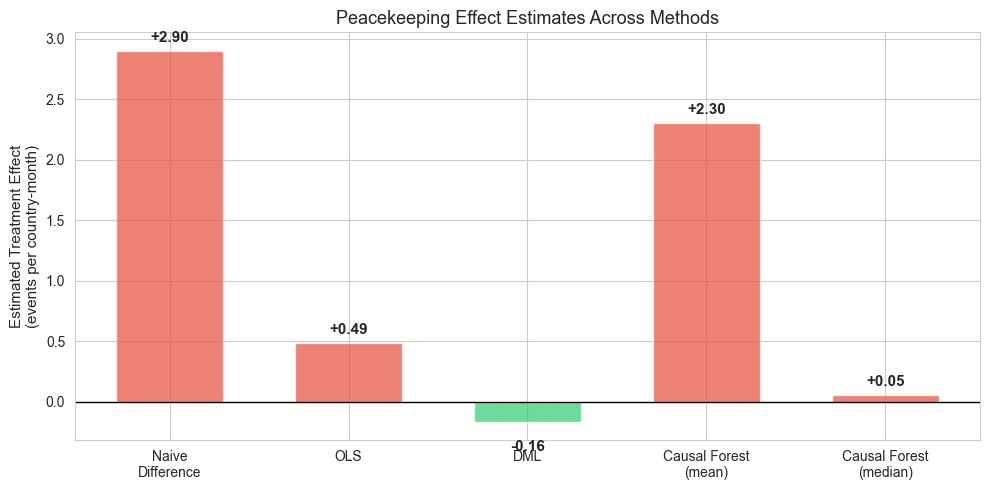

In [16]:
# Summary comparison table
print("=" * 70)
print("COMPARISON OF CAUSAL ESTIMATES")
print("=" * 70)
print(f"\n{'Method':<25} {'Estimate':>10} {'Direction':>20}")
print("-" * 70)
print(f"{'Naive difference':<25} {'+2.90':>10} {'More violence with PK':>20}")
print(f"{'OLS (linear controls)':<25} {'+' + f'{ate_ols:.2f}':<10} {'More violence with PK':>20}")
print(f"{'DML (ML controls)':<25} {f'{ate_dml:.2f}':<10} {'Less violence with PK':>20}")
print(f"{'Causal Forest (mean)':<25} {f'+{cate.mean():.2f}':<10} {'Driven by outliers':>20}")
print(f"{'Causal Forest (median)':<25} {f'+{np.median(cate):.2f}':<10} {'Near zero':>20}")
print("-" * 70)

print(f"\nKey takeaway:")
print(f"  1. Selection bias inflates the naive estimate by ~3 events/month")
print(f"  2. Nonlinear confounding biases OLS: DML flips the sign")
print(f"  3. The average effect is near zero and not statistically significant")
print(f"  4. But 8 of 12 PK countries show negative CATEs (PK reduces violence)")
print(f"  5. Heterogeneity matters: the effect varies by context")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))

methods = ['Naive\nDifference', 'OLS', 'DML', 'Causal Forest\n(mean)', 'Causal Forest\n(median)']
estimates = [2.90, ate_ols, ate_dml, cate.mean(), np.median(cate)]
colors = ['#E74C3C' if e > 0 else '#2ECC71' for e in estimates]

bars = ax.bar(methods, estimates, color=colors, alpha=0.7, width=0.6)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_ylabel('Estimated Treatment Effect\n(events per country-month)', fontsize=11)
ax.set_title('Peacekeeping Effect Estimates Across Methods', fontsize=13)

for bar, val in zip(bars, estimates):
    y_pos = bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.15
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.2f}',
            ha='center', va='bottom' if val >= 0 else 'top', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()